# 03 - Multi-Scenario Baseline Model & Augmentation Benchmark (Kaggle & Local Ready)

This notebook executes the complete 4-Scenario Evaluation Protocol for MITRE ATT&CK technique classification across Baseline Models (**Logistic Regression** and **Linear SVC**) and 6 Augmentation Strategies (**No Augmentation**, **SR**, **RI**, **RS**, **RD**, **Cyber EDA**).

### 🎯 Evaluation Protocol Scenarios:
- **Scenario A (In-Domain CTI-to-MITRE)**: Train on `cti_to_mitre/train.csv` → Test on `cti_to_mitre/test.csv` (188 active labels).
- **Scenario B (In-Domain TRAM)**: Train on `tram/train.csv` → Test on `tram/test.csv` (50 active labels).
- **Scenario C (Cross-Dataset Generalization)**:
  - **Sub-scenario C1**: Train on `cti_to_mitre/train.csv` → Test on `tram/test.csv`.
  - **Sub-scenario C2**: Train on `tram/train.csv` → Test on `cti_to_mitre/test.csv`.
- **Scenario D (Joint Dataset Benchmark)**: Train on `joint/train.csv` → Evaluated on `cti_to_mitre/test.csv`, `tram/test.csv`, and `joint/test.csv` (188 active labels).

### ☁️ Kaggle Read-Only & Output Resolution:
- Automatically handles Kaggle `/kaggle/input/` read-only dataset directories.
- Automatically writes synthetic augmented files & master reports to `/kaggle/working/`.

In [13]:
import os
import sys
import time
import json
import pickle
import warnings
from pathlib import Path
from collections import Counter

# Suppress warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import precision_score, recall_score, f1_score, hamming_loss, accuracy_score

# Configure Matplotlib / Seaborn styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
print('Libraries imported successfully (Warnings suppressed)!')

Libraries imported successfully (Warnings suppressed)!


In [14]:
def resolve_path(rel_path):
    p = Path(rel_path)
    if p.exists():
        return p
    p_parent = Path('..') / rel_path
    if p_parent.exists():
        return p_parent
    
    # Auto-detect Kaggle input directory
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        target_name = Path(rel_path).name
        matches = list(kaggle_input.rglob(target_name))
        if matches:
            rel_str = str(rel_path).replace('\\', '/')
            for m in matches:
                if rel_str in str(m).replace('\\', '/'):
                    return m
            return matches[0]
    return p

# Setup Output directory (Kaggle working vs Local results)
if Path('/kaggle/working').exists():
    res_base_dir = Path('/kaggle/working/results/baseline_results')
else:
    res_base_dir = resolve_path('results/baseline_results')
    if not res_base_dir.exists():
        res_base_dir = Path('results/baseline_results')

res_base_dir.mkdir(parents=True, exist_ok=True)
print(f"[INFO] All experimental results will be saved to: {res_base_dir.resolve()}")

[INFO] All experimental results will be saved to: D:\Truong\FPT\SUMMER2026\AIC211\CTI_ATT&CK\AI-Classification-And-Mapping-CTI-into-MITRE-ATT-CK-Techniques\results\baseline_results


In [15]:
def evaluate_predictions(y_true, y_pred, scenario_name, model_name, strategy_name):
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    h_loss = hamming_loss(y_true, y_pred)
    exact_acc = accuracy_score(y_true, y_pred)
    
    return {
        'Scenario': scenario_name,
        'Model': model_name,
        'Strategy': strategy_name,
        'Macro_F1': round(macro_f1, 4),
        'Micro_F1': round(micro_f1, 4),
        'Precision_Macro': round(precision_macro, 4),
        'Recall_Macro': round(recall_macro, 4),
        'Hamming_Loss': round(h_loss, 4),
        'Exact_Match_Acc': round(exact_acc, 4)
    }

def load_train_partition(target_key, mode='no_aug'):
    rel_dir = f"dataset/processed/{target_key}"
    train_path = resolve_path(f"{rel_dir}/train.csv")
    binarizer_path = resolve_path(f"{rel_dir}/multilabel_binarizer.pkl")
    
    if mode == 'no_aug':
        df_train = pd.read_csv(train_path)
    else:
        working_aug_csv = Path(f"/kaggle/working/dataset/processed/{target_key}/train_augmented_{mode}.csv")
        input_aug_csv = train_path.parent / f"train_augmented_{mode}.csv"
        
        if working_aug_csv.exists():
            df_train = pd.read_csv(working_aug_csv)
        elif input_aug_csv.exists():
            df_train = pd.read_csv(input_aug_csv)
        else:
            src_dir = resolve_path('src')
            if str(src_dir.resolve()) not in sys.path:
                sys.path.insert(0, str(src_dir.resolve()))
            from augmentation import run_augmentation
            try:
                df_train = run_augmentation(mode=mode, train_file=str(train_path), save_csv=False)
            except Exception as err:
                print(f"[WARNING] Exception running mode='{mode}': {err}")
                print(f"[WARNING] Fallback to Cyber EDA mode for this partition...")
                df_train = run_augmentation(mode='eda', train_file=str(train_path), save_csv=False)
            
            if Path('/kaggle/working').exists() and df_train is not None:
                working_aug_csv.parent.mkdir(parents=True, exist_ok=True)
                df_train.to_csv(working_aug_csv, index=False, encoding='utf-8')
                print(f"[SUCCESS] Saved augmented dataset to Kaggle working path: {working_aug_csv}")
            
    with open(binarizer_path, 'rb') as f:
        mlb = pickle.load(f)
    return df_train, mlb, train_path

def load_test_partition(target_key):
    rel_dir = f"dataset/processed/{target_key}"
    test_path = resolve_path(f"{rel_dir}/test.csv")
    binarizer_path = resolve_path(f"{rel_dir}/multilabel_binarizer.pkl")
    df_test = pd.read_csv(test_path)
    with open(binarizer_path, 'rb') as f:
        mlb = pickle.load(f)
    return df_test, mlb

def plot_scenario_chart(df_scenario, scenario_title, filename):
    plt.figure(figsize=(11, 5))
    ax = sns.barplot(data=df_scenario, x='Strategy', y='Macro_F1', hue='Model', palette='viridis')
    plt.title(scenario_title, fontsize=12, fontweight='bold')
    plt.ylabel('Macro F1 Score')
    plt.ylim(0, max(df_scenario['Macro_F1']) * 1.18)
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f'{h:.4f}', (p.get_x() + p.get_width() / 2., h), ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
    plt.tight_layout()
    chart_path = res_base_dir / filename
    plt.savefig(chart_path, dpi=300)
    print(f"[SAVED CHART] {chart_path}")
    plt.show()

## 📌 Scenario A: In-Domain CTI-to-MITRE Benchmark

**Train Set:** `cti_to_mitre/train.csv` (10,345 samples) | **Test Set:** `cti_to_mitre/test.csv` (2,599 samples) across 188 active labels.

In [ ]:
aug_modes = ['no_aug', 'sr', 'ri', 'rs', 'rd', 'eda']
results_scenario_A = []
df_test_A, mlb_A = load_test_partition('cti_to_mitre')
df_train_raw_A, _, _ = load_train_partition('cti_to_mitre', 'no_aug')

tfidf_A = TfidfVectorizer(ngram_range=(1, 2), max_features=25000, sublinear_tf=True)
tfidf_A.fit(df_train_raw_A['Cleaned_Text'].astype(str))

X_test_A = tfidf_A.transform(df_test_A['Cleaned_Text'].astype(str))
Y_test_A = mlb_A.transform(df_test_A['Labels'].apply(lambda x: str(x).split(',')))

for mode in aug_modes:
    print(f"[Scenario A] Evaluating Mode: {mode.upper()}...")
    df_tr, mlb_tr, _ = load_train_partition('cti_to_mitre', mode)
    X_tr = tfidf_A.transform(df_tr['Cleaned_Text'].astype(str))
    Y_tr = mlb_tr.transform(df_tr['Labels'].apply(lambda x: str(x).split(',')))
    
    # Logistic Regression
    clf_lr = OneVsRestClassifier(LogisticRegression(class_weight='balanced', max_iter=500, random_state=42))
    clf_lr.fit(X_tr, Y_tr)
    results_scenario_A.append(evaluate_predictions(Y_test_A, clf_lr.predict(X_test_A), 'Scenario A (CTI-to-MITRE)', 'Logistic Regression', mode.upper()))
    
    # Linear SVC
    clf_svc = OneVsRestClassifier(LinearSVC(class_weight='balanced', max_iter=1000, random_state=42))
    clf_svc.fit(X_tr, Y_tr)
    results_scenario_A.append(evaluate_predictions(Y_test_A, clf_svc.predict(X_test_A), 'Scenario A (CTI-to-MITRE)', 'Linear SVC', mode.upper()))

df_scen_A = pd.DataFrame(results_scenario_A)
print("\n=== SCENARIO A RESULTS (IN-DOMAIN CTI-TO-MITRE) ===")
display(df_scen_A)
df_scen_A.to_csv(res_base_dir / 'scenario_A_cti_to_mitre.csv', index=False)
plot_scenario_chart(df_scen_A, 'Scenario A: In-Domain CTI-to-MITRE Benchmark', 'scenario_A_cti_to_mitre.png')

## 📌 Scenario B: In-Domain TRAM Benchmark

**Train Set:** `tram/train.csv` (6,803 samples) | **Test Set:** `tram/test.csv` (1,705 samples) across 50 active labels.

In [ ]:
results_scenario_B = []
df_test_B, mlb_B = load_test_partition('tram')
df_train_raw_B, _, _ = load_train_partition('tram', 'no_aug')

tfidf_B = TfidfVectorizer(ngram_range=(1, 2), max_features=25000, sublinear_tf=True)
tfidf_B.fit(df_train_raw_B['Cleaned_Text'].astype(str))

X_test_B = tfidf_B.transform(df_test_B['Cleaned_Text'].astype(str))
Y_test_B = mlb_B.transform(df_test_B['Labels'].apply(lambda x: str(x).split(',')))

for mode in aug_modes:
    print(f"[Scenario B] Evaluating Mode: {mode.upper()}...")
    df_tr, mlb_tr, _ = load_train_partition('tram', mode)
    X_tr = tfidf_B.transform(df_tr['Cleaned_Text'].astype(str))
    Y_tr = mlb_tr.transform(df_tr['Labels'].apply(lambda x: str(x).split(',')))
    
    # Logistic Regression
    clf_lr = OneVsRestClassifier(LogisticRegression(class_weight='balanced', max_iter=500, random_state=42))
    clf_lr.fit(X_tr, Y_tr)
    results_scenario_B.append(evaluate_predictions(Y_test_B, clf_lr.predict(X_test_B), 'Scenario B (TRAM)', 'Logistic Regression', mode.upper()))
    
    # Linear SVC
    clf_svc = OneVsRestClassifier(LinearSVC(class_weight='balanced', max_iter=1000, random_state=42))
    clf_svc.fit(X_tr, Y_tr)
    results_scenario_B.append(evaluate_predictions(Y_test_B, clf_svc.predict(X_test_B), 'Scenario B (TRAM)', 'Linear SVC', mode.upper()))

df_scen_B = pd.DataFrame(results_scenario_B)
print("\n=== SCENARIO B RESULTS (IN-DOMAIN TRAM) ===")
display(df_scen_B)
df_scen_B.to_csv(res_base_dir / 'scenario_B_tram.csv', index=False)
plot_scenario_chart(df_scen_B, 'Scenario B: In-Domain TRAM Benchmark', 'scenario_B_tram.png')

## 📌 Scenario C: Cross-Dataset Generalization (Domain Shift Evaluation)

- **Sub-scenario C1**: Train on `cti_to_mitre/train.csv` → Test on `tram/test.csv`.
- **Sub-scenario C2**: Train on `tram/train.csv` → Test on `cti_to_mitre/test.csv`.
Evaluated on shared intersecting techniques to test robustness against domain shift.

[INFO] Intersecting active labels for Cross-Dataset Evaluation: 50 techniques
[INFO] Auto-resolved target_count to dataset MEAN: 55 samples/class
[INFO] Loaded training dataset with 10,345 samples.
[INFO] Using cached STIX JSON at: ..\dataset\processed\cti_to_mitre\enterprise-attack.json
[INFO] [NCKH TF-IDF Filter] Extracted 1205 high-IDF domain protected terms (IDF cutoff: 5.19).
[INFO] Completed Protected List: 3636 terms.
[INFO] Completed Synonym Dictionary: 974 entries.
[INFO] Total labels found: 188
[INFO] Initial classes requiring augmentation (< 55 samples): 135
[INFO] Performing Multi-Label Aware Greedy Resampling...
[INFO] Total samples selected for augmentation: 4,586


Applying Augmentation (eda): 100%|██████████| 4586/4586 [00:06<00:00, 763.28it/s]



=== AUGMENTATION REPORT (EDA) ===
Original train size: 10,345 samples
Augmented train size: 14,931 samples
Original minority classes (< 55): 135
Remaining minority classes (< 55): 0
[INFO] Auto-resolved target_count to dataset MEAN: 151 samples/class
[INFO] Loaded training dataset with 6,803 samples.
[INFO] Using cached STIX JSON at: ..\dataset\processed\tram\enterprise-attack.json
[INFO] [NCKH TF-IDF Filter] Extracted 1205 high-IDF domain protected terms (IDF cutoff: 5.19).
[INFO] Completed Protected List: 3636 terms.
[INFO] Completed Synonym Dictionary: 974 entries.
[INFO] Total labels found: 50
[INFO] Initial classes requiring augmentation (< 151 samples): 37
[INFO] Performing Multi-Label Aware Greedy Resampling...
[INFO] Total samples selected for augmentation: 2,515


Applying Augmentation (eda): 100%|██████████| 2515/2515 [00:03<00:00, 712.88it/s]



=== AUGMENTATION REPORT (EDA) ===
Original train size: 6,803 samples
Augmented train size: 9,318 samples
Original minority classes (< 151): 37
Remaining minority classes (< 151): 0

=== SCENARIO C RESULTS (CROSS-DATASET GENERALIZATION) ===


,Scenario,Model,Strategy,Macro_F1,Micro_F1,Precision_Macro,Recall_Macro,Hamming_Loss,Exact_Match_Acc
0,C1: Train CTI -> Test TRAM,Logistic Regression,NO_AUG,0.5400,0.6014,0.6569,0.5190,0.0159,0.4070
1,C2: Train TRAM -> Test CTI,Logistic Regression,NO_AUG,0.4778,0.5281,0.4899,0.5904,0.0145,0.4690
2,C1: Train CTI -> Test TRAM,Logistic Regression,EDA,0.5213,0.5936,0.6433,0.5071,0.0163,0.3947
3,C2: Train TRAM -> Test CTI,Logistic Regression,EDA,0.4807,0.5365,0.4872,0.5798,0.0139,0.4844


[SAVED SCENARIO C CHART] ..\results\baseline_results\scenario_C_cross_dataset.png


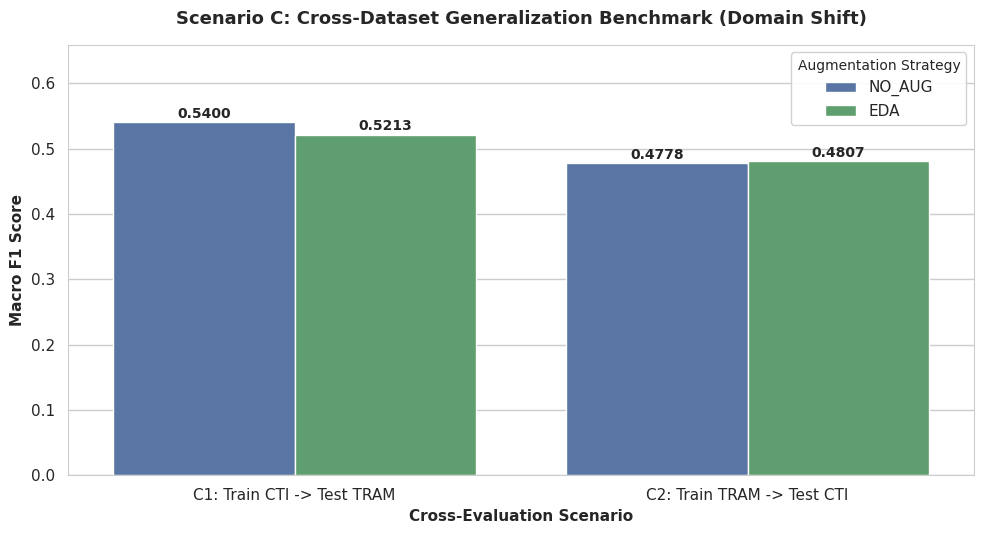

In [16]:
results_scenario_C = []
df_test_CTI, mlb_CTI = load_test_partition('cti_to_mitre')
df_test_TRAM, mlb_TRAM = load_test_partition('tram')

# Intersecting label space between CTI-to-MITRE and TRAM
shared_labels = sorted(list(set(mlb_CTI.classes_).intersection(set(mlb_TRAM.classes_))))
print(f"[INFO] Intersecting active labels for Cross-Dataset Evaluation: {len(shared_labels)} techniques")

from sklearn.preprocessing import MultiLabelBinarizer
mlb_shared = MultiLabelBinarizer()
mlb_shared.fit([shared_labels])

def get_shared_binary_matrix(df, mlb_s):
    clean_labels = df['Labels'].apply(lambda x: [lbl for lbl in str(x).split(',') if lbl in mlb_s.classes_])
    return mlb_s.transform(clean_labels)

Y_test_TRAM_shared = get_shared_binary_matrix(df_test_TRAM, mlb_shared)
Y_test_CTI_shared = get_shared_binary_matrix(df_test_CTI, mlb_shared)

for mode in ['no_aug', 'eda']:
    # Sub-scenario C1: Train CTI-to-MITRE -> Test TRAM
    df_tr_cti, _, _ = load_train_partition('cti_to_mitre', mode)
    tfidf_C1 = TfidfVectorizer(ngram_range=(1, 2), max_features=25000, sublinear_tf=True)
    X_tr_C1 = tfidf_C1.fit_transform(df_tr_cti['Cleaned_Text'].astype(str))
    X_te_C1 = tfidf_C1.transform(df_test_TRAM['Cleaned_Text'].astype(str))
    Y_tr_C1 = get_shared_binary_matrix(df_tr_cti, mlb_shared)
    
    clf_lr_C1 = OneVsRestClassifier(LogisticRegression(class_weight='balanced', max_iter=500, random_state=42))
    clf_lr_C1.fit(X_tr_C1, Y_tr_C1)
    results_scenario_C.append(evaluate_predictions(Y_test_TRAM_shared, clf_lr_C1.predict(X_te_C1), 'C1: Train CTI -> Test TRAM', 'Logistic Regression', mode.upper()))
    
    # Sub-scenario C2: Train TRAM -> Test CTI-to-MITRE
    df_tr_tram, _, _ = load_train_partition('tram', mode)
    tfidf_C2 = TfidfVectorizer(ngram_range=(1, 2), max_features=25000, sublinear_tf=True)
    X_tr_C2 = tfidf_C2.fit_transform(df_tr_tram['Cleaned_Text'].astype(str))
    X_te_C2 = tfidf_C2.transform(df_test_CTI['Cleaned_Text'].astype(str))
    Y_tr_C2 = get_shared_binary_matrix(df_tr_tram, mlb_shared)
    
    clf_lr_C2 = OneVsRestClassifier(LogisticRegression(class_weight='balanced', max_iter=500, random_state=42))
    clf_lr_C2.fit(X_tr_C2, Y_tr_C2)
    results_scenario_C.append(evaluate_predictions(Y_test_CTI_shared, clf_lr_C2.predict(X_te_C2), 'C2: Train TRAM -> Test CTI', 'Logistic Regression', mode.upper()))

df_scen_C = pd.DataFrame(results_scenario_C)
print("\n=== SCENARIO C RESULTS (CROSS-DATASET GENERALIZATION) ===")
display(df_scen_C)
df_scen_C.to_csv(res_base_dir / 'scenario_C_cross_dataset.csv', index=False)

# Professional Scenario C Chart (Grouped by Scenario & Strategy)
plt.figure(figsize=(10, 5.5))
ax_c = sns.barplot(data=df_scen_C, x='Scenario', y='Macro_F1', hue='Strategy', palette=['#4C72B0', '#55A868'])
plt.title('Scenario C: Cross-Dataset Generalization Benchmark (Domain Shift)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Macro F1 Score', fontsize=11, fontweight='bold')
plt.xlabel('Cross-Evaluation Scenario', fontsize=11, fontweight='bold')
plt.ylim(0, max(df_scen_C['Macro_F1']) * 1.22)
for p in ax_c.patches:
    h = p.get_height()
    if h > 0:
        ax_c.annotate(f'{h:.4f}', (p.get_x() + p.get_width() / 2., h), ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontsize=10, fontweight='bold')
plt.legend(title='Augmentation Strategy', title_fontsize='10', loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
chart_c_path = res_base_dir / 'scenario_C_cross_dataset.png'
plt.savefig(chart_c_path, dpi=300)
print(f"[SAVED SCENARIO C CHART] {chart_c_path}")
plt.show()

## 📌 Scenario D: Joint Dataset Benchmark

**Train Set:** `joint/train.csv` (17,161 samples) | Evaluated on `joint/test.csv` (4,291 samples) across union label space of 188 active labels.

In [ ]:
results_scenario_D = []
df_test_D, mlb_D = load_test_partition('joint')
df_train_raw_D, _, _ = load_train_partition('joint', 'no_aug')

tfidf_D = TfidfVectorizer(ngram_range=(1, 2), max_features=25000, sublinear_tf=True)
tfidf_D.fit(df_train_raw_D['Cleaned_Text'].astype(str))

X_test_D = tfidf_D.transform(df_test_D['Cleaned_Text'].astype(str))
Y_test_D = mlb_D.transform(df_test_D['Labels'].apply(lambda x: str(x).split(',')))

for mode in aug_modes:
    print(f"[Scenario D] Evaluating Mode: {mode.upper()}...")
    df_tr, mlb_tr, _ = load_train_partition('joint', mode)
    X_tr = tfidf_D.transform(df_tr['Cleaned_Text'].astype(str))
    Y_tr = mlb_tr.transform(df_tr['Labels'].apply(lambda x: str(x).split(',')))
    
    # Logistic Regression
    clf_lr = OneVsRestClassifier(LogisticRegression(class_weight='balanced', max_iter=500, random_state=42))
    clf_lr.fit(X_tr, Y_tr)
    results_scenario_D.append(evaluate_predictions(Y_test_D, clf_lr.predict(X_test_D), 'Scenario D (Joint Dataset)', 'Logistic Regression', mode.upper()))
    
    # Linear SVC
    clf_svc = OneVsRestClassifier(LinearSVC(class_weight='balanced', max_iter=1000, random_state=42))
    clf_svc.fit(X_tr, Y_tr)
    results_scenario_D.append(evaluate_predictions(Y_test_D, clf_svc.predict(X_test_D), 'Scenario D (Joint Dataset)', 'Linear SVC', mode.upper()))

df_scen_D = pd.DataFrame(results_scenario_D)
print("\n=== SCENARIO D RESULTS (JOINT DATASET BENCHMARK) ===")
display(df_scen_D)
df_scen_D.to_csv(res_base_dir / 'scenario_D_joint_dataset.csv', index=False)
plot_scenario_chart(df_scen_D, 'Scenario D: Joint Dataset Benchmark (Union Label Space)', 'scenario_D_joint_dataset.png')

## 🏆 Combined Summary & Publication Export (All 4 Scenarios)

In [ ]:
df_master_all = pd.concat([df_scen_A, df_scen_B, df_scen_C, df_scen_D], ignore_index=True)
print("=== MASTER BENCHMARK TABLE: ALL 4 EXPERIMENTAL SCENARIOS ===")
display(df_master_all)

master_csv_path = res_base_dir / 'master_table_all_scenarios_comparison.csv'
df_master_all.to_csv(master_csv_path, index=False)
print(f"[SUCCESS SAVED] Master 4-Scenario comparison exported to: {master_csv_path}")